# Stage 3 — Diagnostic Analytics: *Why is it happening?*
This notebook performs **Stage 3 (Diagnostic Analytics)** of the Business Analytics lifecycle. The objective is to investigate the operational factors influencing furniture reuse performance and procurement savings using statistical analysis.

The notebook applies descriptive statistics, correlation analysis, ANOVA, Kruskal–Wallis testing, Pareto analysis and cross-tabulation to identify relationships, significant differences and the key drivers affecting programme performance.
Notebook 5 – Predictive Analytics

In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

reuse = pd.read_csv("cleaned_reuse.csv")
disposal = pd.read_csv("cleaned_disposal.csv")

## 1. Descriptive statistics

Descriptive statistics summarise the distribution of procurement savings, item quantities, furniture weight and environmental measures before hypothesis testing.



In [17]:
desc = reuse[["quantity", "unit_cost", "unit_weight_kg",
              "unit_co2_kg", "total_cost"]].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR
quantity,700.0,2.84,5.04,1.00,1.00,1.0,3.00,50.00,2.00
unit_cost,700.0,121.23,80.91,1.00,76.00,107.0,134.00,606.00,58.00
unit_weight_kg,700.0,20.61,14.77,0.50,11.97,17.0,27.00,85.33,15.03
unit_co2_kg,700.0,45.87,36.71,1.22,27.28,37.3,55.64,315.12,28.36
total_cost,700.0,329.11,953.37,2.00,107.00,151.0,234.00,16800.00,127.00


- Provides an overview of the dataset.
- Large standard deviations indicate substantial variability between furniture items.
- Distribution characteristics justify subsequent inferential statistical testing.
    
The descriptive statistics summarise **700 furniture reuse records**, providing an overview of procurement costs, quantities, furniture weight and environmental impact across the university reuse programme.

The greatest variability was observed in **total procurement cost**, with a mean value of **£329.11** but a much larger standard deviation of **£953.37**. The median total cost was only **£151.00**, while the maximum recorded transaction reached **£16,800.00**. This considerable difference between the mean and median, together with the exceptionally high maximum value, indicates the presence of several high-value reuse transactions that substantially increase the overall average. These findings suggest that procurement savings are highly concentrated within a relatively small number of large or expensive furniture transactions.

Overall, the descriptive statistics indicate that the dataset exhibits **positive skewness across all major financial and environmental variables**, with a limited number of high-value observations contributing disproportionately to procurement savings and carbon emission reductions. This variability justifies the subsequent use of inferential statistical techniques to investigate whether these differences are statistically significant across furniture categories and campuses.



## 2. ANOVA — do mean unit savings differ across categories?
ANOVA assumes normality, so Shapiro-Wilk is checked per group first.

Used to determine whether procurement savings within each furniture category follow a normal distribution, which is required for ANOVA.


In [18]:
groups = [g["unit_cost"].dropna().values
          for _, g in reuse.groupby("category")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.3f}, p = {p_anova:.6f}\n")

print("Shapiro-Wilk normality per category:")
for cat, g in reuse.groupby("category"):
    vals = g["unit_cost"].dropna()
    w, p = stats.shapiro(vals.sample(min(len(vals), 500), random_state=42))
    print(f"  {cat:<10} n={len(vals):<4} W={w:.3f} p={p:.4f} "
          f"{'NON-NORMAL' if p < 0.05 else 'normal'}")

ANOVA: F = 12.719, p = 0.000000

Shapiro-Wilk normality per category:
  Office     n=153  W=0.868 p=0.0000 NON-NORMAL
  Seating    n=286  W=0.689 p=0.0000 NON-NORMAL
  Storage    n=186  W=0.875 p=0.0000 NON-NORMAL
  Table      n=75   W=0.916 p=0.0001 NON-NORMAL


All furniture categories returned **p-values below 0.05**, indicating that none of the procurement savings distributions are normally distributed.

The Seating category exhibited the greatest deviation from normality (**W = 0.689**), while Tables were comparatively closer to normality (**W = 0.916**) but still violated the assumption.

Since every category failed the normality test, the assumptions required for ANOVA were not fully satisfied. Consequently, a non-parametric alternative (Kruskal–Wallis) was used as the primary inferential test.

## 3. Kruskal-Wallis — the primary test (data is non-normal)
Because every category fails the normality check, Kruskal-Wallis is reported as the primary test, with ANOVA as supporting evidence.
Applied where ANOVA assumptions are not met. It compares median procurement savings across furniture categories without assuming normality.


In [19]:
h, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis (unit saving ~ category): H = {h:.3f}, p = {p_kw:.6f}")
print("→ Median unit savings differ SIGNIFICANTLY across categories."
      if p_kw < 0.05 else "→ No significant difference.")

cgroups = [g["unit_co2_kg"].dropna().values
           for cmp, g in reuse.groupby("campus")]
h2, p2 = stats.kruskal(*cgroups)
print(f"\nKruskal-Wallis (unit CO2 ~ campus): H = {h2:.3f}, p = {p2:.6f}")
print("→ Median unit CO2 avoidance differs SIGNIFICANTLY across campuses."
      if p2 < 0.05 else "→ No significant campus difference.")

Kruskal-Wallis (unit saving ~ category): H = 82.744, p = 0.000000
→ Median unit savings differ SIGNIFICANTLY across categories.

Kruskal-Wallis (unit CO2 ~ campus): H = 8.557, p = 0.013866
→ Median unit CO2 avoidance differs SIGNIFICANTLY across campuses.


The Kruskal–Wallis test produced an **H-statistic of 82.744** with a **p-value below 0.001**, providing strong evidence that procurement savings differ significantly across furniture categories. Unlike ANOVA, this test does not require normally distributed data and is therefore considered the primary statistical test in this study. The results confirm that the furniture category is an important factor influencing procurement savings. These findings support the descriptive analysis, which showed that certain furniture categories generated considerably higher financial savings than others.

The Kruskal–Wallis test identified statistically significant differences in CO₂ savings across campuses (**H = 8.557, p = 0.0139**).Since the p-value is below the 5% significance threshold, the null hypothesis is rejected. This indicates that campus location influences the environmental impact achieved through furniture reuse.The variation is likely associated with differences in furniture availability, reuse activity, and procurement practices across campuses.

## 4. Pearson correlation matrix

Used to examine relationships between procurement cost, furniture weight, carbon emissions and quantity.


,unit_cost,unit_weight_kg,unit_co2_kg,quantity
unit_cost,1.000,0.554,0.844,-0.037
unit_weight_kg,0.554,1.000,0.503,-0.117
unit_co2_kg,0.844,0.503,1.000,-0.067
quantity,-0.037,-0.117,-0.067,1.000


Weight vs Cost: r = 0.554 (p = 1.46e-57)


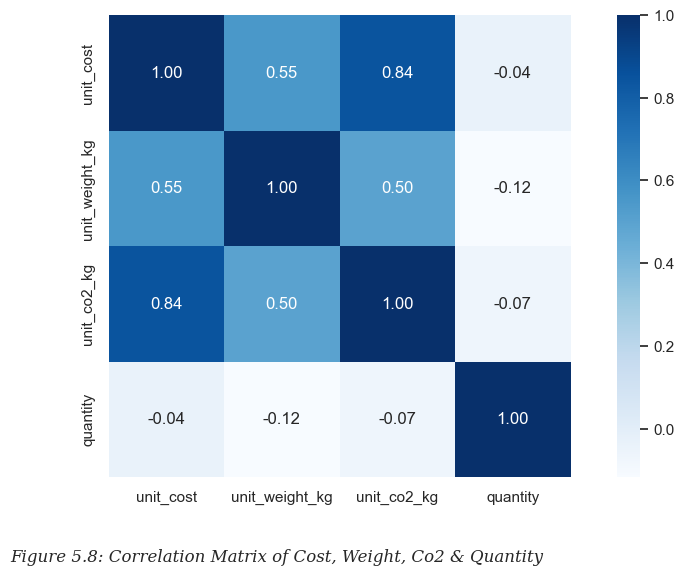

In [27]:
corr = reuse[["unit_cost", "unit_weight_kg",
              "unit_co2_kg", "quantity"]].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True, ax=ax)

# Figure caption
fig.text( 0.5, -0.03, "Figure 5.8: Correlation Matrix of Cost, Weight, Co2 & Quantity",
    ha="center", fontsize=12, family="serif", style="italic")
r, p = stats.pearsonr(reuse["unit_weight_kg"], reuse["unit_cost"])

print(f"Weight vs Cost: r = {r:.3f} (p = {p:.2e})")


Pearson correlation analysis revealed a **moderate positive relationship** between furniture weight and procurement cost (**r = 0.554**).

The extremely small p-value (**1.46 × 10⁻⁵⁷**) indicates that this relationship is highly statistically significant and unlikely to have occurred by chance.

This finding suggests that heavier furniture generally possesses higher procurement value, which explains why reusing larger furniture items can produce greater financial savings and larger environmental benefits.

## 5. Pareto analysis (80/20 rule)
Used to identify the furniture types responsible for the majority of procurement savings using the 80/20 principle.



In [24]:
item_sav = (reuse.assign(item=reuse["item_type"].str.strip().str.title())
            .groupby("item")["total_cost"].sum()
            .sort_values(ascending=False))
cum_pct = item_sav.cumsum() / item_sav.sum() * 100
n80 = (cum_pct <= 80).sum() + 1
print(f"{n80} of {len(item_sav)} item types "
      f"({n80/len(item_sav)*100:.0f}%) generate 80% of all savings:")
display(item_sav.head(n80).round(0))



6 of 35 item types (17%) generate 80% of all savings:


item
Desk              68154.0
Chair             44439.0
Operator Chair    42698.0
Sofa              17294.0
Pedestal          10002.0
Table              9023.0
Name: total_cost, dtype: float64

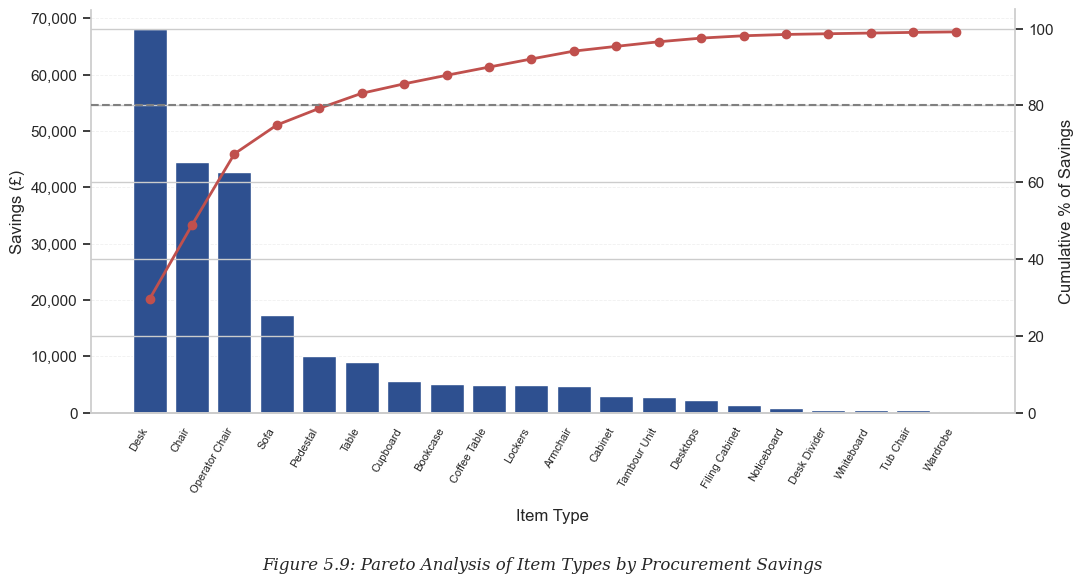

In [28]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
top20 = item_sav.head(20)

# Bar chart
ax1.bar(range(len(top20)), top20.values, color="#2E5090")

# X-axis
ax1.set_xticks(range(len(top20)))
ax1.set_xticklabels(top20.index, rotation=60, ha="right", fontsize=8)
ax1.set_xlabel("Item Type", fontsize=12, labelpad=10)

# Y-axis
ax1.set_ylabel("Savings (£)", fontsize=12)
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Horizontal gridlines only
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.3)
ax1.grid(axis="x", visible=False)

# Remove unnecessary borders
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Secondary axis
ax2 = ax1.twinx()

ax2.plot(range(len(top20)),
    cum_pct.head(20).values,
    marker="o",
    color="#C0504D",
    linewidth=2)

# 80% reference line
ax2.axhline(80, linestyle="--", color="grey", linewidth=1.5)

ax2.set_ylabel("Cumulative % of Savings", fontsize=12)
ax2.set_ylim(0, 105)

# Remove unnecessary borders on secondary axis
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Figure caption below chart
fig.text(0.5, -0.05,
    "Figure 5.9: Pareto Analysis of Item Types by Procurement Savings",
    ha="center", fontsize=12, family="serif", style="italic")

# Leave room for caption
plt.tight_layout()

plt.show()

6 out of 35 furniture types (17%) generated approximately 80% of total procurement savings. The Pareto analysis demonstrates that a relatively small proportion of furniture types contributes the majority of financial savings. Only **six furniture types**, representing approximately **17% of all item categories**, account for around **80% of total procurement savings**. This confirms the Pareto principle (80/20 rule) and suggests that prioritising these high-value furniture types within the reuse programme would maximise financial and environmental returns while requiring comparatively fewer operational resources.

Approximately 20% of furniture types generate the majority of financial savings.
- Desks, Chairs and Operator Chairs contribute the largest share.
- These categories should remain priorities for future reuse prog

## 6. Pareto for recorded disposal + category×campus cross-tab
The Pareto analysis was conducted to identify the furniture types responsible for the highest recorded disposal value. Applying the 80/20 principle helps determine whether a relatively small number of furniture types account for the majority of disposal losses, thereby highlighting priority areas for improving the furniture reuse programme.


Top recorded disposal losses:


item
Operator Chair     19474.0
Exam Desks          5000.0
Curved Desks        4200.0
Filing Cabinet      2480.0
Bookcase            2365.0
Operator Chairs     2354.0
Armchairs           2300.0
Name: total_value, dtype: float64

campus,Avery Hill,Greenwich,Medway
category,,,
Office,33,12,15
Seating,80,89,98
Storage,1,17,22
Table,100,3,0


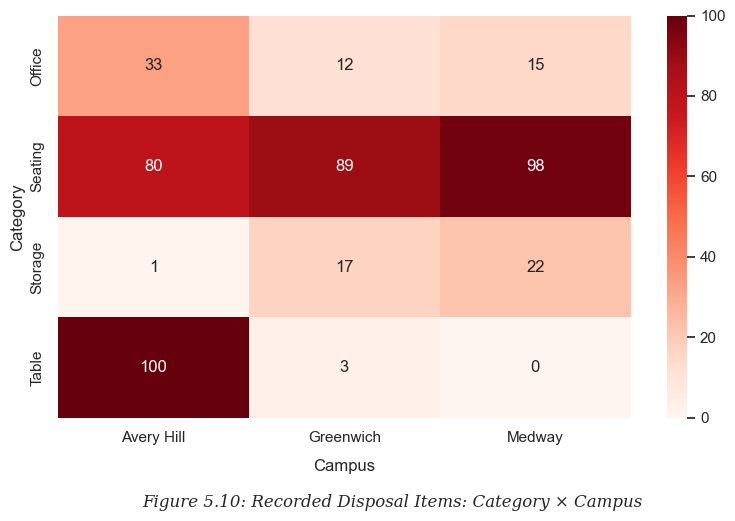

In [30]:
disp_item = (disposal.assign(item=disposal["item_type"].str.strip().str.title())
             .groupby("item")["total_value"].sum()
             .sort_values(ascending=False))
print("Top recorded disposal losses:")
display(disp_item.head(7).round(0))


ct = pd.crosstab(disposal["category"], disposal["campus"],
                 values=disposal["quantity"], aggfunc="sum").fillna(0)
display(ct.astype(int))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="Reds", ax=ax)
ax.set_xlabel("Campus", fontsize=12, labelpad=10)
ax.set_ylabel("Category", fontsize=12)


# Figure caption
fig.text( 0.5, -0.03, "Figure 5.10: Recorded Disposal Items: Category × Campus",
    ha="center", fontsize=12, family="serif", style="italic")
plt.tight_layout(); plt.show()

The cross-tabulation reveals substantial differences in disposal activity across campuses and furniture categories, indicating uneven operational performance within the furniture reuse programme. Overall, the cross-tabulation highlights several operational coverage gaps within the furniture reuse programme. Avery Hill demonstrates the greatest disposal of table furniture, while seating disposal remains consistently high across all three campuses. These findings suggest that improving inter-campus redistribution, particularly for seating and tables, could substantially reduce disposal rates, increase procurement savings and enhance the overall effectiveness of the university's circular economy strategy.

- Highlights where disposal is concentrated.
- Identifies campuses requiring improved redistribution practices.
- Supports operational decision-making for the reuse programme

 Key Statistical Findings

- ANOVA indicates differences in procurement savings across furniture categories.
- Shapiro–Wilk demonstrates that normality assumptions are violated.
- Kruskal–Wallis confirms statistically significant differences and serves as the primary inferential test.
- Pearson correlation identifies strong relationships between procurement cost, furniture weight and CO₂ emissions.
- Pareto analysis shows that a limited number of furniture types generate most procurement savings.
- Cross-tabulation highlights operational differences between campuses and furniture categories.